### BUILD A BASIC CHAT BOT USING LANG-GRAPH USING (GRAPH_API)

In [1]:
from typing_extensions import TypedDict
from typing  import Annotated
from langgraph.graph import StateGraph,START , END
from langgraph.graph.message import add_messages


In [2]:
class State(TypedDict):
    messages : Annotated[list,add_messages]
    
graph_builder  = StateGraph(State)


In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
LLM = ChatGroq(
    model = "qwen/qwen3.8-27b",
    temperature = 0,
    verbose=True
)
LLM

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.2', 'langchain': '1.3.14'}}, output_version=None, client=<groq.resources.chat.completions.Completions object at 0x00000176F4233770>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000176F43D8590>, model_name='qwen/qwen3.8-27b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [25]:
def chatbot(state:State):
    return {
        "messages":[LLM.invoke(state["messages"])]
    }

In [39]:
## add nodes to graphs
graph_builder.add_node("chatbot",chatbot)
## add edges to graph
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

graph = graph_builder.compile()




Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


ValueError: Node `chatbot` already present.

In [ ]:
##visualize the graph
from IPython.display import display,Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
res = graph.invoke({"messages": "hello"})
res["messages"][-1]

## Chatbot with TOOLS

In [6]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("what is langgraph")

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian Cr

In [7]:
#custom funtion 

def multiply(a:int,b:int)->int:
    """multiply a and b

    Args:
        a (int): my first int
        b (int): second int

    Returns:
        int: output 
    """

In [8]:
tools = [tool,multiply]
llm_with_tools = LLM.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.2', 'langchain': '1.3.14'}}, output_version=None, client=<groq.resources.chat.completions.Completions object at 0x00000176F4233770>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000176F43D8590>, model_name='qwen/qwen3.8-27b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look 

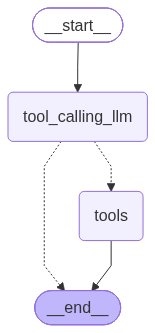

In [9]:
#creating the state graph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## node defination
def tool_calling_llm(state:State):
    return{
        "messages":[llm_with_tools.invoke(state["messages"])]
    }

#creating the graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))
#adding edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools",END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
graph.invoke({"messages":["user","what is the recent ai news"]})

{'messages': [HumanMessage(content='user', additional_kwargs={}, response_metadata={}, id='eb6287e8-49eb-47fc-9c7e-0c41d386115f'),
  HumanMessage(content='what is the recent ai news', additional_kwargs={}, response_metadata={}, id='b26a30f1-e4b5-4232-a44d-e9f6e38c0c97'),
  AIMessage(content='Here are some of the most significant recent AI news stories from late May and early June 2025:\n\n### 1. **OpenAI Launches GPT-5**\n*   **What happened:** OpenAI officially released **GPT-5**, its most advanced model to date. It features a "unified" architecture that dynamically routes queries between different specialized models (including a new "GPT-5 mini" and "GPT-5 nano") to optimize for speed, cost, and reasoning capability.\n*   **Key Feature:** It boasts significant improvements in coding, math, and complex reasoning, and is designed to be more "agentic," meaning it can better plan and execute multi-step tasks autonomously.\n*   **Source:** [OpenAI Blog](https://openai.com/blog/gpt-5), [Th